<a href="https://colab.research.google.com/github/saraisabella0206-ctrl/INTEGRACION-DE-DATOS-Y-PROSPECTIVA-/blob/main/Reto_parcial_1_Sara_Isabella_Casta%C3%B1o_Ram%C3%ADrez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Reto parcial 1:** Entidad prestadora de salud

Una entidad prestadora de salud quiere mejorar la eficiencia en la prestación de sus servicios de salud, para lo cual quiere cerrar una de sus sucursales(Sabaneta). Para reubicar a sus pacientes, se quiere determinar cuál de las demás sucursales tiene mayor afinidad con Sabaneta utilizando la variable de referencia Glucose (variable representativa de pacientes con Diabetes). Para lo anterior, se utilizan las siguientes técnicas:

- Teoría de la Credibilidad: para establecer la afinidad entre Sabaneta y cada una de las demás sucursales (Bello, Medellín, Envigado, Caldas, Itaguí).

- Método Aceptación/Rechazo I (Valor de pertenencia): Para clasificar pacientes de Sabaneta en la sucursal con mayor credibilidad.

- Método de Aceptación/Rechazo II: Para integrar pacientes comparando valores de pertenencia internos vs externos.

- Método de Aceptación/Rechazo III: Para integrar pacientes mediante componente aleatorio.



#**0. Cargo las librerías de trabajo e identifico los datos con los que voy a trabajar**

In [ ]:
import numpy as np
import pandas as pd #Librería para manejo datos
import seaborn as sns #Librería para el trabajo estadístico
import matplotlib.pyplot as plt #Librería

from google.colab import drive
drive.mount('/content/drive')

datos = '/content/drive/MyDrive/Colab Notebooks/Excels/3. Parcial - medical_attention_data.xlsx'


Mounted at /content/drive


In [ ]:
#Guardo cada base de datos en variables diferentes
XDB_sabaneta= pd.read_excel(datos, sheet_name=4) #Sucursal que va cerrar (base de datos interna)
XDB_bello = pd.read_excel(datos, sheet_name=0)
XDB_medellin = pd.read_excel(datos, sheet_name=1)
XDB_envigado = pd.read_excel(datos, sheet_name=2)
XDB_itagui = pd.read_excel(datos, sheet_name=3)
XDB_caldas = pd.read_excel(datos, sheet_name=5)

XDB_itagui.head()

,PatientID,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diabetes,Branch
0,ITA-0001,89,39,736,25.563,0.557,59,0,Itagui
1,ITA-0002,99,31,238,49.786,1.190,46,0,Itagui
2,ITA-0003,110,18,593,49.004,1.117,76,0,Itagui
3,ITA-0004,70,47,71,47.335,0.159,23,1,Itagui
4,ITA-0005,40,50,369,34.553,1.018,33,0,Itagui


Nota: Como se mencionó anteriormente la variable mediante la cual se va analizar la afinidad es "Glucose". Por esto, como la base de datos de Itagui no la tiene, esta sucursal no se va tomar en cuenta para el estudio porque no tenemos forma de saber si se presenta afinidad entre ambas bases de datos y podría ser contraproducente para el sistema de salud realizar asignaciones aleatorias.

In [ ]:
#@title Variable glucose
#Se extrae la variable de cada base de datos con la que se va hacer el análisis: Glucose
LDA_sabaneta=np.array(XDB_sabaneta['Glucose']) #Sucursal que va cerrar (base de datos interna)
LDA_bello=np.array(XDB_bello['Glucose'])
LDA_medellin=np.array(XDB_medellin['Glucose'])
LDA_envigado=np.array(XDB_envigado['Glucose'])
LDA_caldas=np.array(XDB_caldas['Glucose'])

print(f"La sucursal que cerrará (Sabaneta) tiene actualmente: {len(LDA_sabaneta)} pacientes")

# Contar valores faltantes (NaNs) en cada array de Glucose
lda_arrays = {
    "Sabaneta": LDA_sabaneta,
    "Bello": LDA_bello,
    "Medellín": LDA_medellin,
    "Envigado": LDA_envigado,
    "Caldas": LDA_caldas
}

print("\nValores faltantes (NaNs) en la columna 'Glucose' para cada sucursal:")
for name, arr in lda_arrays.items():
    nan_count = np.sum(np.isnan(arr))
    print(f"  {name}: {nan_count}")

La sucursal que cerrará (Sabaneta) tiene actualmente: 621 pacientes

Valores faltantes (NaNs) en la columna 'Glucose' para cada sucursal:
  Sabaneta: 0
  Bello: 0
  Medellín: 0
  Envigado: 0
  Caldas: 0


#**1. Caracterización de distribuciones de probabilidad**

In [ ]:
# @title Caracterización de Distribuciones de Probabilidad
def caracterizacion(LDA, nombre=""):

  #Se procede con la creación de la distribución
  plt.figure(figsize=(10,5))
  sns.histplot(LDA,bins=10,kde=True)
  plt.xlabel("Glucose (mg/dL)")
  plt.title(f"Distribución de Glucose - {nombre}")
  plt.grid()
  plt.show()

  #Se procede con la caracterización de cada una de las variables
  np.set_printoptions(suppress=True)
  NI=10    #Indica el número de clusters
  counts,bin_edges=np.histogram(LDA,bins=NI)
  print("El número de datos por intervalo es:")
  print(counts)
  print("Los intervalos inferiores:")
  print(bin_edges[:-1])
  print("Los intervalos superiores:")
  print(bin_edges[1:])
  XC=(bin_edges[:-1]+bin_edges[1:])/2

  #Se configura la tabla de los datos
  Tabla=np.column_stack((bin_edges[:-1],bin_edges[1:],XC,counts))
  df=pd.DataFrame(Tabla,columns=['LI','LS','XC','ND'])
  print(df)

  #Se procede con la estimación de la media, sigma, asimetría y kurtosis
  fr=counts/np.sum(counts)
  u=np.sum(XC*fr)
  sigma2=np.sum(fr*(XC-u)**2)
  sigma=np.sqrt(sigma2)
  Cas=np.sum(fr*(XC-u)**3)/sigma**3
  Kur=(np.sum(fr*(XC-u)**4)/sigma**4)-3

  print(f"\nMedia: {u:.4f}")
  print(f"Desviación Estándar: {sigma:.4f}")
  print(f"Coeficiente de Asimetría: {Cas:.4f}")
  print(f"Kurtosis: {Kur:.4f}")

  return u,sigma,Cas,Kur,df

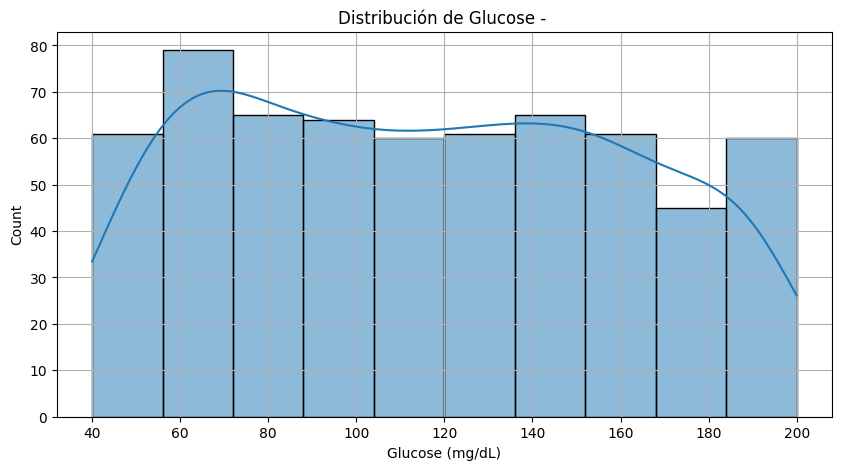

El número de datos por intervalo es:
[61 79 65 64 60 61 65 61 45 60]
Los intervalos inferiores:
[ 40.  56.  72.  88. 104. 120. 136. 152. 168. 184.]
Los intervalos superiores:
[ 56.  72.  88. 104. 120. 136. 152. 168. 184. 200.]
      LI     LS     XC    ND
0   40.0   56.0   48.0  61.0
1   56.0   72.0   64.0  79.0
2   72.0   88.0   80.0  65.0
3   88.0  104.0   96.0  64.0
4  104.0  120.0  112.0  60.0
5  120.0  136.0  128.0  61.0
6  136.0  152.0  144.0  65.0
7  152.0  168.0  160.0  61.0
8  168.0  184.0  176.0  45.0
9  184.0  200.0  192.0  60.0

Media: 116.6119
Desviación Estándar: 45.6241
Coeficiente de Asimetría: 0.1115
Kurtosis: -1.2023


In [ ]:
# @title Sabaneta (base de datos interna)
# Se hace caracterización
usa,sigmasa,Cassa,Kursa,dfsa=caracterizacion(LDA_sabaneta)

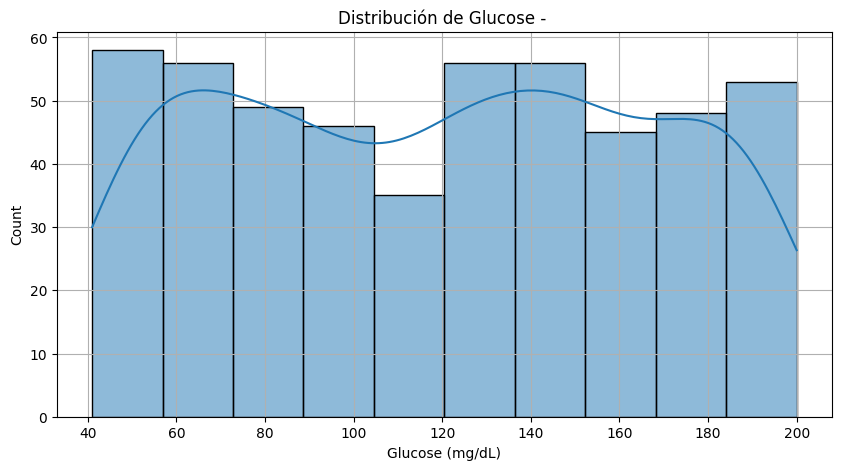

El número de datos por intervalo es:
[58 56 49 46 35 56 56 45 48 53]
Los intervalos inferiores:
[ 41.   56.9  72.8  88.7 104.6 120.5 136.4 152.3 168.2 184.1]
Los intervalos superiores:
[ 56.9  72.8  88.7 104.6 120.5 136.4 152.3 168.2 184.1 200. ]
      LI     LS      XC    ND
0   41.0   56.9   48.95  58.0
1   56.9   72.8   64.85  56.0
2   72.8   88.7   80.75  49.0
3   88.7  104.6   96.65  46.0
4  104.6  120.5  112.55  35.0
5  120.5  136.4  128.45  56.0
6  136.4  152.3  144.35  56.0
7  152.3  168.2  160.25  45.0
8  168.2  184.1  176.15  48.0
9  184.1  200.0  192.05  53.0

Media: 119.3914
Desviación Estándar: 46.8535
Coeficiente de Asimetría: 0.0068
Kurtosis: -1.2771


In [ ]:
# @title Bello (base de datos externa 1)
# Se hace caracterización
ube,sigmabe,Casbe,Kurbe,dfbe=caracterizacion(LDA_bello)

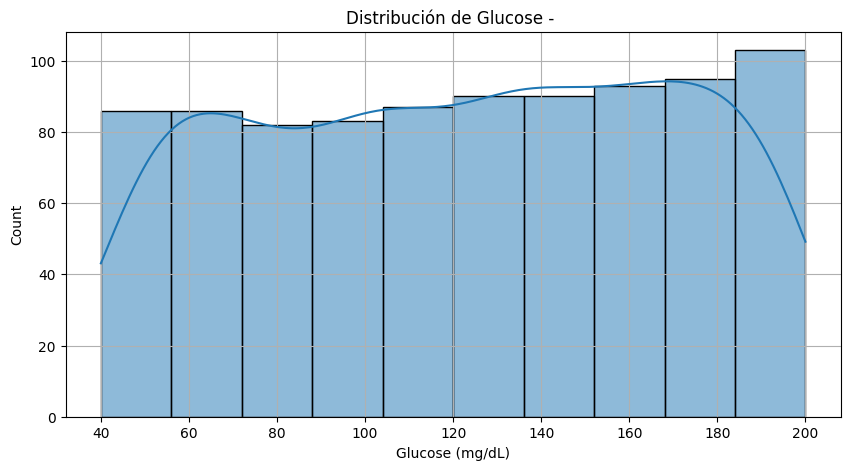

El número de datos por intervalo es:
[ 86  86  82  83  87  90  90  93  95 103]
Los intervalos inferiores:
[ 40.  56.  72.  88. 104. 120. 136. 152. 168. 184.]
Los intervalos superiores:
[ 56.  72.  88. 104. 120. 136. 152. 168. 184. 200.]
      LI     LS     XC     ND
0   40.0   56.0   48.0   86.0
1   56.0   72.0   64.0   86.0
2   72.0   88.0   80.0   82.0
3   88.0  104.0   96.0   83.0
4  104.0  120.0  112.0   87.0
5  120.0  136.0  128.0   90.0
6  136.0  152.0  144.0   90.0
7  152.0  168.0  160.0   93.0
8  168.0  184.0  176.0   95.0
9  184.0  200.0  192.0  103.0

Media: 122.6369
Desviación Estándar: 46.4631
Coeficiente de Asimetría: -0.0732
Kurtosis: -1.2369


In [ ]:
# @title Medellín (base de datos externa 2)
# Se hace caracterización
ume,sigmame,Casme,Kurme,dfme=caracterizacion(LDA_medellin)

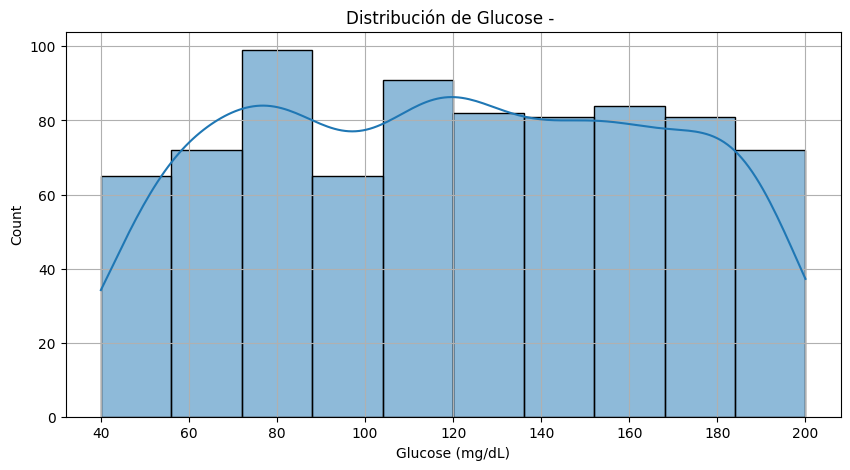

El número de datos por intervalo es:
[65 72 99 65 91 82 81 84 81 72]
Los intervalos inferiores:
[ 40.  56.  72.  88. 104. 120. 136. 152. 168. 184.]
Los intervalos superiores:
[ 56.  72.  88. 104. 120. 136. 152. 168. 184. 200.]
      LI     LS     XC    ND
0   40.0   56.0   48.0  65.0
1   56.0   72.0   64.0  72.0
2   72.0   88.0   80.0  99.0
3   88.0  104.0   96.0  65.0
4  104.0  120.0  112.0  91.0
5  120.0  136.0  128.0  82.0
6  136.0  152.0  144.0  81.0
7  152.0  168.0  160.0  84.0
8  168.0  184.0  176.0  81.0
9  184.0  200.0  192.0  72.0

Media: 120.9091
Desviación Estándar: 44.6271
Coeficiente de Asimetría: -0.0121
Kurtosis: -1.1857


In [ ]:
# @title Envigado (base de datos externa 3)
# Se hace caracterización
uen,sigmaen,Casen,Kuren,df_en=caracterizacion(LDA_envigado)

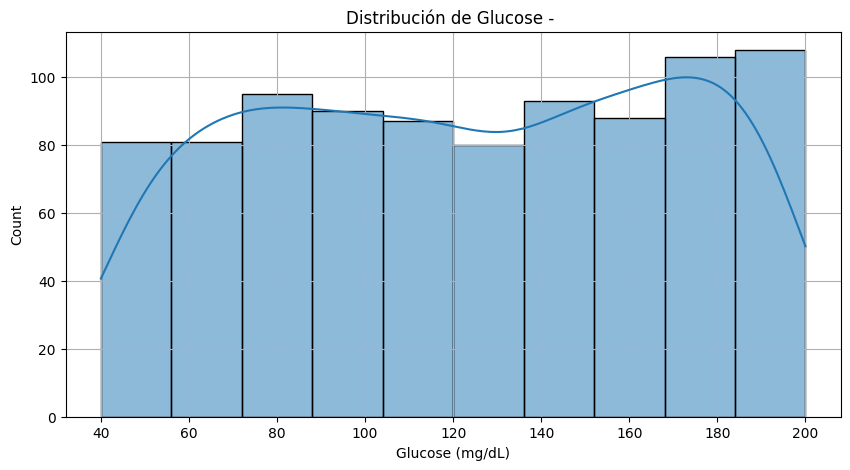

El número de datos por intervalo es:
[ 81  81  95  90  87  80  93  88 106 108]
Los intervalos inferiores:
[ 40.  56.  72.  88. 104. 120. 136. 152. 168. 184.]
Los intervalos superiores:
[ 56.  72.  88. 104. 120. 136. 152. 168. 184. 200.]
      LI     LS     XC     ND
0   40.0   56.0   48.0   81.0
1   56.0   72.0   64.0   81.0
2   72.0   88.0   80.0   95.0
3   88.0  104.0   96.0   90.0
4  104.0  120.0  112.0   87.0
5  120.0  136.0  128.0   80.0
6  136.0  152.0  144.0   93.0
7  152.0  168.0  160.0   88.0
8  168.0  184.0  176.0  106.0
9  184.0  200.0  192.0  108.0

Media: 123.3883
Desviación Estándar: 46.4903
Coeficiente de Asimetría: -0.0651
Kurtosis: -1.2589


In [ ]:
# @title Caldas (base de datos externa 4)
# Se hace caracterización
uca,sigmaca,Casca,Kurca,dfca=caracterizacion(LDA_caldas)

In [ ]:
#@title Resumen distribuciones de probabilidad
data = {
    'Sucursal': ['Sabaneta', 'Bello', 'Medellín', 'Envigado', 'Caldas'],
    'Media': [usa, ube, ume, uen, uca],
    'Desviación Estándar': [sigmasa, sigmabe, sigmame, sigmaen, sigmaca],
    'Coeficiente de Asimetría': [Cassa, Casbe, Casme, Casen, Casca],
    'Kurtosis': [Kursa, Kurbe, Kurme, Kuren, Kurca]
}

df_estadisticas = pd.DataFrame(data)
print(df_estadisticas)

   Sucursal       Media  Desviación Estándar  Coeficiente de Asimetría  \
0  Sabaneta  116.611916            45.624094                  0.111522   
1     Bello  119.391434            46.853461                  0.006787   
2  Medellín  122.636872            46.463117                 -0.073215   
3  Envigado  120.909091            44.627095                 -0.012111   
4    Caldas  123.388339            46.490331                 -0.065124   

   Kurtosis  
0 -1.202306  
1 -1.277090  
2 -1.236939  
3 -1.185729  
4 -1.258911  


#**2.Estimación de la teoria de la credibilidad**

In [ ]:
#@title Sabaneta vs Bello
#Se procede del valor esperado de la varianza
NDo=len(LDA_sabaneta);NDe=len(LDA_bello)
EPV=(sigmasa*NDo+sigmabe*NDe)/(NDo+NDe)

#Se procede con la estimación del Valor Hipotetico de la Media
uh=(usa*NDo+ube*NDe)/(NDo+NDe)
VHM=((NDo*usa**2+NDe*ube**2)/(NDo+NDe))-uh**2

#Se procede con la estimación del fc
fc=EPV/VHM

#Se procede con la estimación de la credibilidad
Cr=NDo/(NDo+fc)

print("La credibilidad es:",Cr)

La credibilidad es: 0.9625251562257526


In [ ]:
#@title Sabaneta vs Medellin
#Se procede del valor esperado de la varianza
NDo=len(LDA_sabaneta);NDe=len(LDA_medellin)
EPV=(sigmasa*NDo+sigmame*NDe)/(NDo+NDe)

#Se procede con la estimación del Valor Hipotetico de la Media
uh=(usa*NDo+ume*NDe)/(NDo+NDe)
VHM=((NDo*usa**2+NDe*ume**2)/(NDo+NDe))-uh**2

#Se procede con la estimación del fc
fc=EPV/VHM

#Se procede con la estimación de la credibilidad
Cr2=NDo/(NDo+fc)

print("La credibilidad es:",Cr2)

La credibilidad es: 0.991611008379182


In [ ]:
#@title Sabaneta vs Envigado
#Se procede del valor esperado de la varianza
NDo=len(LDA_sabaneta);NDe=len(LDA_envigado)
EPV=(sigmasa*NDo+sigmaen*NDe)/(NDo+NDe)

#Se procede con la estimación del Valor Hipotetico de la Media
uh=(usa*NDo+uen*NDe)/(NDo+NDe)
VHM=((NDo*usa**2+NDe*uen**2)/(NDo+NDe))-uh**2

#Se procede con la estimación del fc
fc=EPV/VHM

#Se procede con la estimación de la credibilidad
Cr3=NDo/(NDo+fc)

print("La credibilidad es:",Cr3)

La credibilidad es: 0.9842971635246126


In [ ]:
#@title Sabaneta vs caldas
#Se procede del valor esperado de la varianza
NDo=len(LDA_sabaneta);NDe=len(LDA_caldas)
EPV=(sigmasa*NDo+sigmaca*NDe)/(NDo+NDe)

#Se procede con la estimación del Valor Hipotetico de la Media
uh=(usa*NDo+uca*NDe)/(NDo+NDe)
VHM=((NDo*usa**2+NDe*uca**2)/(NDo+NDe))-uh**2

#Se procede con la estimación del fc
fc=EPV/VHM

#Se procede con la estimación de la credibilidad
Cr4=NDo/(NDo+fc)

print("La credibilidad es:",Cr4)

La credibilidad es: 0.9933350589140462


In [ ]:
#@title Ranking de credibilidad
# Se crea un diccionario con las credibilidades calculadas
credibilidades = {
    "Bello": Cr,
    "Medellín": Cr2,
    "Envigado": Cr3,
    "Caldas": Cr4
}

# Se ordena el diccionario por credibilidad de mayor a menor
credibilidad_ranking = sorted(credibilidades.items(), key=lambda item: item[1], reverse=True)

print("Ranking de Credibilidad (Sabaneta vs otras sucursales):\n")
for sucursal, credibilidad in credibilidad_ranking:
    print(f"  {sucursal}: {credibilidad:.4f}")

# Identificar la sucursal con mayor afinidad
sucursal_mas_afin = credibilidad_ranking[0][0]
max_credibilidad = credibilidad_ranking[0][1]

print(f"\nLa sucursal externa con la mayor afinidad a Sabaneta, según la Teoría de la Credibilidad, es '{sucursal_mas_afin}' con un valor de credibilidad de {max_credibilidad:.4f}.")

Ranking de Credibilidad (Sabaneta vs otras sucursales):

  Caldas: 0.9933
  Medellín: 0.9916
  Envigado: 0.9843
  Bello: 0.9625

La sucursal externa con la mayor afinidad a Sabaneta, según la Teoría de la Credibilidad, es 'Caldas' con un valor de credibilidad de 0.9933.


#**3.Método Aceptación/Rechazo I (Valor de pertenencia)**

A partir de la aplicación de la teoría de la credibilidad, se determinó que la sucursal Caldas presenta la mayor afinidad con la sucursal Sabaneta, razón por la cual se procedió a evaluar la integración de los pacientes mediante el método de aceptación/rechazo basado en valor de pertenencia (VP), considerando como criterio de aceptación aquellos registros con VP >0.9


Número de datos en sucursal sabaneta: 621
Número de datos en sucursal caldas antes de la integración: 909
Los datos integrados son: 166
Porcentaje de datos de Sabaneta integrados: 26.73%
Número de datos en la sucursal Caldas después de la integración: 1075


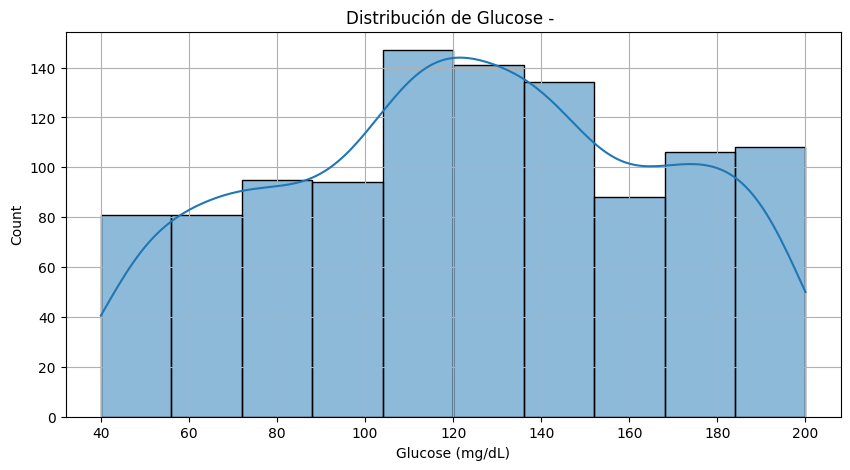

El número de datos por intervalo es:
[ 81  81  95  94 147 141 134  88 106 108]
Los intervalos inferiores:
[ 40.  56.  72.  88. 104. 120. 136. 152. 168. 184.]
Los intervalos superiores:
[ 56.  72.  88. 104. 120. 136. 152. 168. 184. 200.]
      LI     LS     XC     ND
0   40.0   56.0   48.0   81.0
1   56.0   72.0   64.0   81.0
2   72.0   88.0   80.0   95.0
3   88.0  104.0   96.0   94.0
4  104.0  120.0  112.0  147.0
5  120.0  136.0  128.0  141.0
6  136.0  152.0  144.0  134.0
7  152.0  168.0  160.0   88.0
8  168.0  184.0  176.0  106.0
9  184.0  200.0  192.0  108.0

Media: 123.6986
Desviación Estándar: 43.0690
Coeficiente de Asimetría: -0.0886
Kurtosis: -0.9961


'''''''''''''''''''''''''''''''''''''''''
La media de los datos de Caldas antes de la integración es: 123.38833883388338
La media de los datos integrados es: 123.69860465116278
La discrepancia entre las medias es: 0.25145473244202515


'''''''''''''''''''''''''''''''''''''''''
Sigma de los datos de Caldas antes de la integración es

In [ ]:
# @title -
#Reviso cuántos datos tiene actualmente la sucursal Sabaneta
num_datos_sabaneta = len(LDA_sabaneta)
print(f"Número de datos en sucursal sabaneta: {num_datos_sabaneta}")

# Contar el número de datos en LDA_caldas
num_datos_caldas = len(LDA_caldas)
print(f"Número de datos en sucursal caldas antes de la integración: {num_datos_caldas}")

#Se procede a integrar los datos de sabaneta cuyo valor de pertenencias sea mayor a 90%
LDAint=np.copy(np.array(LDA_caldas))   #Variable de Integración
LDAe=np.array(LDA_sabaneta)

m1=0
for k in range(len(LDAe)):
  VP=np.exp(-0.5*((uca-LDAe[k,])/sigmaca)**2)

  if VP>0.9:
      m1=m1+1   #Contador de cuantos datos integrados
      LDAint=np.append(LDAint,LDAe[k])
      #print("El dato a integrar es:",LDAe[k])

print("Los datos integrados son:",m1)

# Calcular y mostrar el porcentaje de datos de LDA_sabaneta que se pudieron integrar
porcentaje_integrado = (m1 / len(LDA_sabaneta)) * 100
print(f"Porcentaje de datos de Sabaneta integrados: {porcentaje_integrado:.2f}%")


# Contar el número de datos en LDAint después de la integración
print(f"Número de datos en la sucursal Caldas después de la integración: {len(LDAint)}")

#Validamos propiedades estadísticas
ui,sigmai,Casi,Kuri,dfi=caracterizacion(LDAint)
print("\n")
print("'''''''''''''''''''''''''''''''''''''''''")
print("La media de los datos de Caldas antes de la integración es:",uca)
print("La media de los datos integrados es:",ui)
disc_u=np.abs((uca-ui)/uca)*100  #Cual es la discrepancia entre las medias
print("La discrepancia entre las medias es:",disc_u)


print("\n")
print("'''''''''''''''''''''''''''''''''''''''''")
print("Sigma de los datos de Caldas antes de la integración es:",sigmaca)
print("Sigma de los datos integrados es:",sigmai)
disc_sigma=np.abs((sigmaca-sigmai)/sigmaca)*100  #Cual es la discrepancia entre las sigmas
print("La discrepancia entre las sigmas es:",disc_sigma)


**Interpretación**

De los 621 registros correspondientes a la sucursal Sabaneta, 166 pacientes cumplieron el criterio de aceptación (corresponde al 26.73% de los datos). Estos registros fueron integrados a la base de datos de la sucursal Caldas, incrementando el tamaño de la muestra de 909 a 1075 registros.

El análisis estadístico posterior a la integración muestra que la media de la variable de referencia en la sucursal Caldas pasó de 123.39 a 123.70, lo que implica una discrepancia de apenas 0.25 unidades. Este resultado indica que la incorporación de los nuevos datos no altera significativamente la tendencia central de la distribución, lo cual sugiere que los pacientes integrados presentan características similares a las ya existentes en la sucursal receptora.

Por otra parte, la desviación estándar disminuyó de 46.49 a 43.07, lo que indica una reducción en la dispersión de los datos después de la integración. Esto ocurre porque el criterio VP > 0.9 solo permite integrar pacientes con características muy similares a las de la sucursal Caldas, descartando valores más alejados de la distribución. Como resultado, los datos quedan más concentrados alrededor de la media, lo que reduce la variabilidad del conjunto integrado.

#**4.Método Aceptación/Rechazo II**

Con este método se halla VPo y VPe

Cantidad de datos de Sabaneta que se integraron: 292
Porcentaje de datos de Sabaneta integrados: 47.02%
Total de datos después de integración: 1201


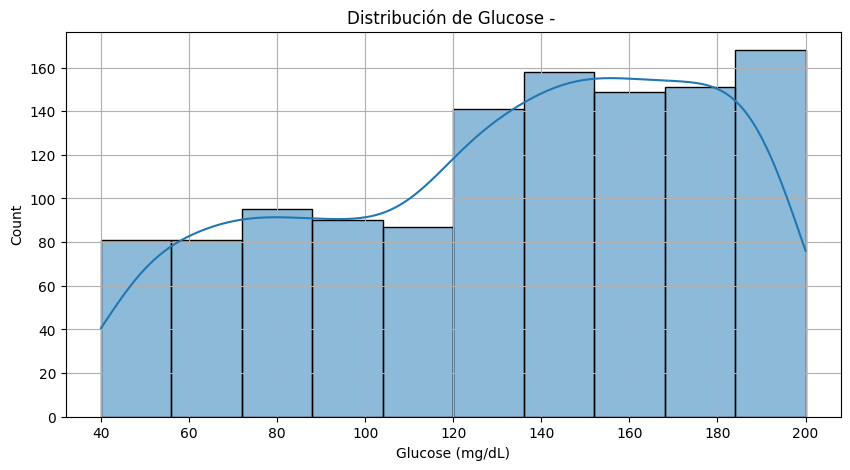

El número de datos por intervalo es:
[ 81  81  95  90  87 141 158 149 151 168]
Los intervalos inferiores:
[ 40.  56.  72.  88. 104. 120. 136. 152. 168. 184.]
Los intervalos superiores:
[ 56.  72.  88. 104. 120. 136. 152. 168. 184. 200.]
      LI     LS     XC     ND
0   40.0   56.0   48.0   81.0
1   56.0   72.0   64.0   81.0
2   72.0   88.0   80.0   95.0
3   88.0  104.0   96.0   90.0
4  104.0  120.0  112.0   87.0
5  120.0  136.0  128.0  141.0
6  136.0  152.0  144.0  158.0
7  152.0  168.0  160.0  149.0
8  168.0  184.0  176.0  151.0
9  184.0  200.0  192.0  168.0

Media: 131.9967
Desviación Estándar: 44.6409
Coeficiente de Asimetría: -0.3652
Kurtosis: -1.0162


'''''''''''''''''''''''''''''''''''''''''
La media de los datos de Caldas antes de la integración es: 123.38833883388338
La media de los datos integrados es: 131.99666944213155
La discrepancia entre las medias es: 6.976616015422239


'''''''''''''''''''''''''''''''''''''''''
Sigma de los datos de Caldas antes de la integración es: 

In [ ]:
#@title -
LDAint2=np.copy(LDA_caldas)

m2=0
for k in range(len(LDA_sabaneta)):   #Se recorren uno a uno los datos de Sabaneta para ver cuál de los dos valors VPo-VPe es mayor
  VPo=np.exp(-0.5*((uca-LDA_sabaneta[k])/sigmaca)**2)   ##VPo: Qué tanto se parece el dato de Sabaneta a los datos de la sucursal Caldas?
  VPe=np.exp(-0.5*((usa-LDA_sabaneta[k])/sigmasa)**2)     ##VPe: Qué tan representativo es el dato en la distribución de Sabaneta

  if VPo>VPe:
    m2=m2+1
    LDAint2=np.append(LDAint2,LDA_sabaneta[k])

print("Cantidad de datos de Sabaneta que se integraron:",m2)
porcentaje_integrado2 = (m2 / len(LDA_sabaneta)) * 100
print(f"Porcentaje de datos de Sabaneta integrados: {porcentaje_integrado2:.2f}%")
print("Total de datos después de integración:", len(LDAint2))


#Validamos propiedades estadísticas
ui2,sigmai2,Casi2,Kuri2,dfi2=caracterizacion(LDAint2)
print("\n")
print("'''''''''''''''''''''''''''''''''''''''''")
print("La media de los datos de Caldas antes de la integración es:",uca)
print("La media de los datos integrados es:",ui2)
disc_u2=np.abs((uca-ui2)/uca)*100  #Cual es la discrepancia entre las medias
print("La discrepancia entre las medias es:",disc_u2)


print("\n")
print("'''''''''''''''''''''''''''''''''''''''''")
print("Sigma de los datos de Caldas antes de la integración es:",sigmaca)
print("Sigma de los datos integrados es:",sigmai2)
disc_sigma2=np.abs((sigmaca-sigmai2)/sigmaca)*100  #Cual es la discrepancia entre las sigmas
print("La discrepancia entre las sigmas es:",disc_sigma2)


**Interpretación**

Al aplicar el segundo método de integración basado en el criterio
VPo>VPe, se integraron 292 registros provenientes de la sucursal Sabaneta, lo que corresponde aproximadamente al 47.02 % de los datos originales. Este porcentaje es considerablemente mayor que el obtenido en el método anterior basado en VP > 0.9, lo que indica que este criterio de aceptación es menos restrictivo, permitiendo la incorporación de un mayor número de pacientes al conjunto de datos de la sucursal Caldas. Como resultado, el total de registros aumentó de 909 a 1201 datos.

Desde el punto de vista de las medidas de tendencia central, se observa que la media pasó de 123.39 a 131.99, generando una discrepancia de aproximadamente 6.98 unidades. Este cambio es significativamente mayor que el observado en el primer método de integración, lo que sugiere que los datos provenientes de Sabaneta presentan valores promedio más altos en la variable analizada. En consecuencia, la incorporación de una mayor cantidad de registros provoca un desplazamiento de la media de la distribución hacia valores superiores.

En cuanto a la dispersión, la desviación estándar disminuyó de 46.49 a 44.64, lo que sugiere que, aunque se integró una mayor cantidad de registros, la variabilidad general del conjunto de datos se mantiene relativamente estable.

En términos generales, los resultados de este método permite integrar una mayor proporción de datos, lo que incrementa el tamaño de la muestra, pero también genera cambios más notorios en la media de la distribución. Esto sugiere que este método es menos conservador que el basado en VP>0.9, ya que incorpora registros con menor similitud estadística respecto a la base de datos original de la sucursal Caldas.

#**5.Método Aceptación/Rechazo III**

Este método establece cuotas de aceptación para los números que se quieran integrar f(X)/g(x) > aleatorio(). Esto garantiza que la forma de distirbución original no se distornen.


Cantidad de datos de Sabaneta que se integraron: 599
Porcentaje de datos de Sabaneta integrados: 96.46%
Total de datos después de integración: 1508


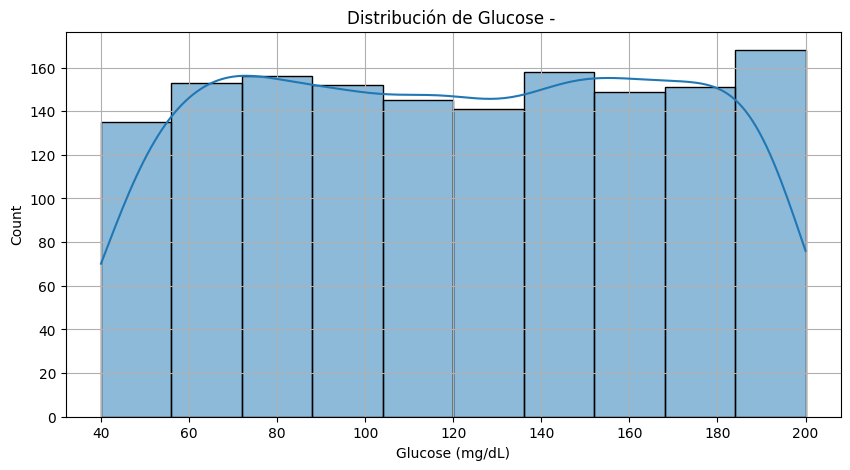

El número de datos por intervalo es:
[135 153 156 152 145 141 158 149 151 168]
Los intervalos inferiores:
[ 40.  56.  72.  88. 104. 120. 136. 152. 168. 184.]
Los intervalos superiores:
[ 56.  72.  88. 104. 120. 136. 152. 168. 184. 200.]
      LI     LS     XC     ND
0   40.0   56.0   48.0  135.0
1   56.0   72.0   64.0  153.0
2   72.0   88.0   80.0  156.0
3   88.0  104.0   96.0  152.0
4  104.0  120.0  112.0  145.0
5  120.0  136.0  128.0  141.0
6  136.0  152.0  144.0  158.0
7  152.0  168.0  160.0  149.0
8  168.0  184.0  176.0  151.0
9  184.0  200.0  192.0  168.0

Media: 121.3899
Desviación Estándar: 46.1088
Coeficiente de Asimetría: -0.0120
Kurtosis: -1.2409


'''''''''''''''''''''''''''''''''''''''''
La media de los datos de Caldas antes de la integración es: 123.38833883388338
La media de los datos integrados es: 121.38992042440319
La discrepancia entre las medias es: 1.619616917098339


'''''''''''''''''''''''''''''''''''''''''
Sigma de los datos de Caldas antes de la integración es: 

In [ ]:
#@title -
#Código para hacer número aleatorios
LDAint3=np.copy(np.array(LDA_caldas))
m3 = 0 # Inicializamos m3 antes del bucle

for k in range(len(LDA_sabaneta)):
  VPo=np.exp(-0.5*((uca-LDA_sabaneta[k])/sigmaca)**2) #¿Qué tanto se parece el dato externos a los internos?
  VPe=np.exp(-0.5*((usa-LDA_sabaneta[k])/sigmasa)**2)  #¿Qué tan representativo es un dato externo?
  aleatorio=np.random.rand()

  if (VPo/VPe)>aleatorio:
    m3=m3+1
    LDAint3=np.append(LDAint3,LDA_sabaneta[k])

print("Cantidad de datos de Sabaneta que se integraron:",m3)
porcentaje_integrado3 = (m3 / len(LDA_sabaneta)) * 100
print(f"Porcentaje de datos de Sabaneta integrados: {porcentaje_integrado3:.2f}%")
print("Total de datos después de integración:", len(LDAint3))

#Validamos propiedades estadísticas
ui3,sigmai3,Casi3,Kuri3,dfi3=caracterizacion(LDAint3)
print("\n")
print("'''''''''''''''''''''''''''''''''''''''''")
print("La media de los datos de Caldas antes de la integración es:",uca)
print("La media de los datos integrados es:",ui3)
duoui3=np.abs((uca-ui3)/uca)*100
print("La discrepancia entre las medias es:",duoui3)

print("\n")
print("'''''''''''''''''''''''''''''''''''''''''")
print("Sigma de los datos de Caldas antes de la integración es:",sigmaca)
print("Sigma de los datos integrados es:",sigmai3)
disc_sigma3=np.abs((sigmaca-sigmai3)/sigmaca)*100  #Cual es la discrepancia entre las sigmas
print("La discrepancia entre las sigmas es:",disc_sigma3)

**Interpretación**

Al aplicar el método III de aceptación/rechazo con componente aleatorio, se integraron 599 registros provenientes de la sucursal Sabaneta, lo que representa aproximadamente 96.46 % de los datos originales. Esto indica que este método es mucho menos restrictivo que los anteriores, ya que permite incorporar prácticamente la totalidad de los registros al conjunto de datos de la sucursal Caldas. Como resultado, el número total de datos pasó de 909 a 1508 registros.

En cuanto a las medidas de tendencia central, la media cambió de 123.39 a 121.39, lo que representa una discrepancia de aproximadamente 1.62 unidades. Aunque se integró una cantidad muy alta de datos, el cambio en la media no es excesivamente grande, lo que sugiere que, en términos generales, la distribución de los datos provenientes de Sabaneta no es radicalmente diferente a la de Caldas.

Respecto a la dispersión, la desviación estándar pasó de 46.49 a 46.11, mostrando una variación mínima. Esto indica que la variabilidad del conjunto de datos prácticamente se mantiene, lo cual es consistente con el hecho de que el método integra una gran proporción de registros sin aplicar un filtrado estricto.

En términos generales, este método permite realizar una integración masiva de datos manteniendo niveles de dispersión similares a los del conjunto inicial, aunque con una ligera variación en la media.

#**Resumen ejecutivo**

Con el objetivo de mejorar la eficiencia en la prestación de los servicios de salud, se evaluó el cierre de la sucursal Sabaneta y la posible redistribución de sus pacientes en otras sedes. Mediante la teoría de la credibilidad se determinó que la sucursal Caldas presenta la mayor afinidad estadística con Sabaneta, por lo que se seleccionó como la principal sede receptora.

Posteriormente, se aplicaron tres métodos de integración de datos. El Método I (valor de pertenencia, VP > 0.9) integró 166 pacientes (26.7%), aplicando un criterio estricto de similitud. El Método II (VPo > VPe) permitió integrar 292 pacientes (47.02%), utilizando un criterio de aceptación menos restrictivo. Finalmente, el Método III (aceptación/rechazo con componente aleatorio) integró 599 pacientes (96.46%), incorporando prácticamente la totalidad de los registros de la sucursal Sabaneta sin cambios significativos en las medidas de tendencia central y dispersión.

Considerando los resultados obtenidos, se recomienda el Método III, ya que permite integrar la mayor cantidad de pacientes y, por lo tanto, garantiza una mayor cobertura en la atención al momento de cerrar la sucursal de Sabaneta, manteniendo al mismo tiempo una estructura estadística similar en la base de datos resultante.

En caso de querer observar las conclusiones de cada método en particular remitirse a la parte superior, donde al final de cada método se explica cada uno al detalle.